In [1]:
import pandas as pd
from DataLoader import DataLoader
from Strategies import StrategyEngine

In [19]:
class BacktestEngine:
    """
    Simple long-only backtest driven by integer Signal column:
      +1 = enter (buy with all cash), -1 = exit (sell all shares), 0 = no trade.
    """

    def __init__(self, strategy_df, initial_cash=10000.0):
        try:
            if strategy_df is None or strategy_df.empty:
                raise ValueError("strategy_df is empty; run the strategy first.")
            if initial_cash <= 0:
                raise ValueError("initial_cash must be positive.")
            required = {"Close", "Signal"}
            missing = required - set(strategy_df.columns)
            if missing:
                raise KeyError(f"strategy_df missing columns: {sorted(missing)}")

            self.df = strategy_df.copy()
            self.initial_cash = float(initial_cash)
            self.transactions = []
            self.equity_curve = None
        except Exception:
            raise

    def run(self):
        """
        Execute trades bar-by-bar.
        Sets self.equity_curve (DataFrame) and returns (equity_curve, trades_df).
        """
        try:
            cash = self.initial_cash
            shares = 0.0
            records = []
            self.transactions = []

            for ts, row in self.df.iterrows():
                price = float(row["Close"])
                signal = int(row["Signal"])

                if price <= 0 or pd.isna(price):
                    raise ValueError(f"Invalid price at {ts}: {price}")

                if signal == 1:
                    if cash > 0:
                        bought = cash / price
                        shares += bought
                        trade_value = cash
                        cash = 0.0
                        self.transactions.append(
                            {
                                "Date": ts,
                                "Action": "BUY",
                                "Price": price,
                                "Shares": bought,
                                "Trade Value": trade_value,
                                "Cash After": cash,
                                "Shares After": shares,
                            }
                        )
                elif signal == -1:
                    if shares > 0:
                        proceeds = shares * price
                        sold = shares
                        cash += proceeds
                        self.transactions.append(
                            {
                                "Date": ts,
                                "Action": "SELL",
                                "Price": price,
                                "Shares": sold,
                                "Trade Value": proceeds,
                                "Cash After": cash,
                                "Shares After": 0.0,
                            }
                        )
                        shares = 0.0

                equity = cash + shares * price
                records.append(
                    {
                        "Cash": cash,
                        "Shares": shares,
                        "Close": price,
                        "Equity": equity,
                        "Signal": signal,
                    }
                )

            self.equity_curve = pd.DataFrame(records, index=self.df.index)
            trades_df = (
                pd.DataFrame(self.transactions)
                if self.transactions
                else pd.DataFrame(
                    columns=[
                        "Date",
                        "Action",
                        "Price",
                        "Shares",
                        "Trade Value",
                        "Cash After",
                        "Shares After",
                    ]
                )
            )
            return self.equity_curve, trades_df
        except Exception as exc:
            raise RuntimeError(f"Backtest failed: {exc}") from exc

In [46]:
loader = DataLoader("AAPL", "2023-04-01", "2026-05-01")
ohlcv = loader.get_data()

engine_strat = StrategyEngine(ohlcv)
strategy_df = engine_strat.moving_average_crossover(short_window=20, long_window=50)

bt = BacktestEngine(strategy_df,400)
equity_curve, trades = bt.run()

print("Final equity:", float(equity_curve["Equity"].iloc[-1]))
print("Number of trades:", len(trades))
display(equity_curve.tail())
display(trades.head(10))

Variables are successfully initialised


[*********************100%***********************]  1 of 1 completed


Final equity: 452.8506994692636
Number of trades: 19


,Cash,Shares,Close,Equity,Signal
Date,,,,,
2026-04-24,0.0,1.66888,271.059998,452.366710,0
2026-04-27,0.0,1.66888,267.609985,446.609052,0
2026-04-28,0.0,1.66888,270.709991,451.782592,0
2026-04-29,0.0,1.66888,270.170013,450.881433,0
2026-04-30,0.0,1.66888,271.350006,452.850699,0


,Date,Action,Price,Shares,Trade Value,Cash After,Shares After
0,2023-06-13,BUY,180.942215,2.210651,400.000000,0.000000,2.210651
1,2023-08-16,SELL,174.524658,2.210651,385.813025,385.813025,0.000000
2,2023-11-14,BUY,185.512817,2.079711,385.813025,0.000000,2.079711
3,2024-01-17,SELL,180.801743,2.079711,376.015351,376.015351,0.000000
4,2024-05-08,BUY,181.091919,2.076378,376.015351,0.000000,2.076378
5,2024-08-20,SELL,225.031784,2.076378,467.251139,467.251139,0.000000
6,2024-08-27,BUY,226.541870,2.062538,467.251139,0.000000,2.062538
7,2024-11-19,SELL,227.039734,2.062538,468.278001,468.278001,0.000000
8,2024-12-03,BUY,241.331680,1.940392,468.278001,0.000000,1.940392
9,2025-01-27,SELL,228.611160,1.940392,443.595209,443.595209,0.000000


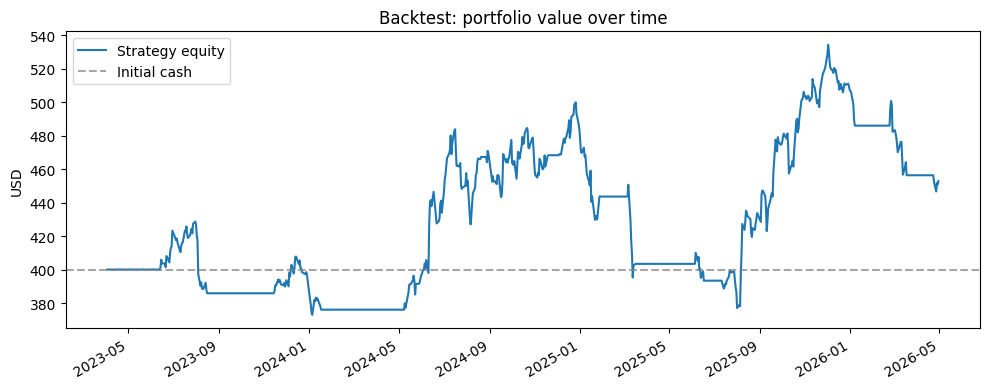

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(equity_curve.index, equity_curve["Equity"], label="Strategy equity")
ax.axhline(bt.initial_cash, color="gray", linestyle="--", alpha=0.7, label="Initial cash")
ax.set_title("Backtest: portfolio value over time")
ax.set_ylabel("USD")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed

Variables are successfully initialised


Final equity: 4636.776009273038
Number of trades: 25


,Cash,Shares,Close,Equity,Signal
Date,,,,,
2026-04-24,0.0,17.087805,271.059998,4631.820400,0
2026-04-27,0.0,17.087805,267.609985,4572.867264,0
2026-04-28,0.0,17.087805,270.709991,4625.839564,0
2026-04-29,0.0,17.087805,270.170013,4616.612524,0
2026-04-30,0.0,17.087805,271.350006,4636.776009,0


,Date,Action,Price,Shares,Trade Value,Cash After,Shares After
0,2022-07-20,BUY,150.166519,26.637096,4000.000000,0.000000,26.637096
1,2022-09-19,SELL,151.790039,26.637096,4043.245856,4043.245856,0.000000
2,2022-11-21,BUY,145.673981,27.755443,4043.245856,0.000000,27.755443
3,2022-11-29,SELL,138.941925,27.755443,3856.394669,3856.394669,0.000000
4,2022-12-01,BUY,145.969223,26.419231,3856.394669,0.000000,26.419231
5,2022-12-19,SELL,130.280792,26.419231,3441.918387,3441.918387,0.000000
6,2023-02-03,BUY,152.061554,22.635034,3441.918387,0.000000,22.635034
7,2023-08-16,SELL,174.524643,22.635034,3950.371161,3950.371161,0.000000
8,2023-11-14,BUY,185.512802,21.294332,3950.371161,0.000000,21.294332
9,2024-01-17,SELL,180.801727,21.294332,3850.051971,3850.051971,0.000000


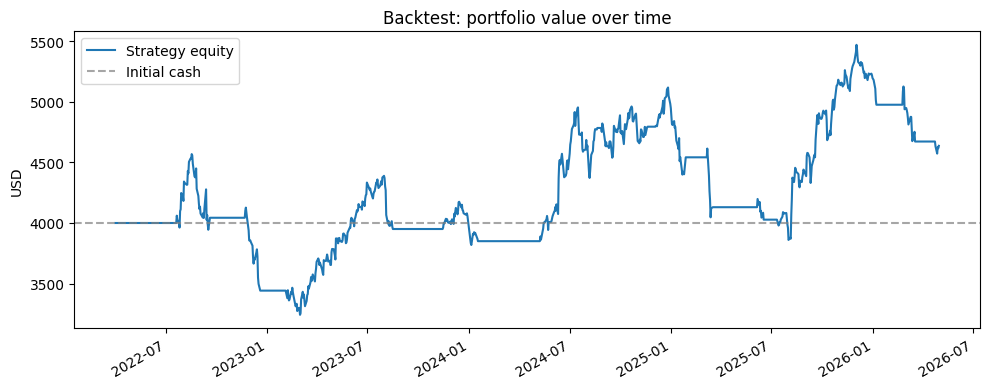

In [50]:
loader = DataLoader("AAPL", "2022-04-01", "2026-05-01")
ohlcv = loader.get_data()

engine_strat = StrategyEngine(ohlcv)
strategy_df = engine_strat.moving_average_crossover(short_window=20, long_window=50)

bt = BacktestEngine(strategy_df,4000)
equity_curve, trades = bt.run()

print("Final equity:", float(equity_curve["Equity"].iloc[-1]))
print("Number of trades:", len(trades))
display(equity_curve.tail())
display(trades.head(10))
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(equity_curve.index, equity_curve["Equity"], label="Strategy equity")
ax.axhline(bt.initial_cash, color="gray", linestyle="--", alpha=0.7, label="Initial cash")
ax.set_title("Backtest: portfolio value over time")
ax.set_ylabel("USD")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()